# Model testing

Looking at some modelling method and how they would work on the data.
- Linear Regression
- XGBoost
- Statistical Modelling

In [1]:
#load plays data
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plays = pd.read_csv('/Users/seanlee/Desktop/Github_repositories/Practice-repo/data/plays.csv')

In [2]:
#Linear regression practice: predict yardsGained from yardsToGo
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

X = plays[['yardsToGo']]
y = plays['yardsGained']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"coefficient: {model.coef_[0]:.3f}")
print(f"intercept: {model.intercept_:.3f}")
print(f"R^2: {r2_score(y_test, y_pred):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f} yards")

coefficient: 0.150
intercept: 4.249
R^2: 0.008
MAE: 5.82 yards


/Users/seanlee/Desktop/Github_repositories/Practice-repo/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


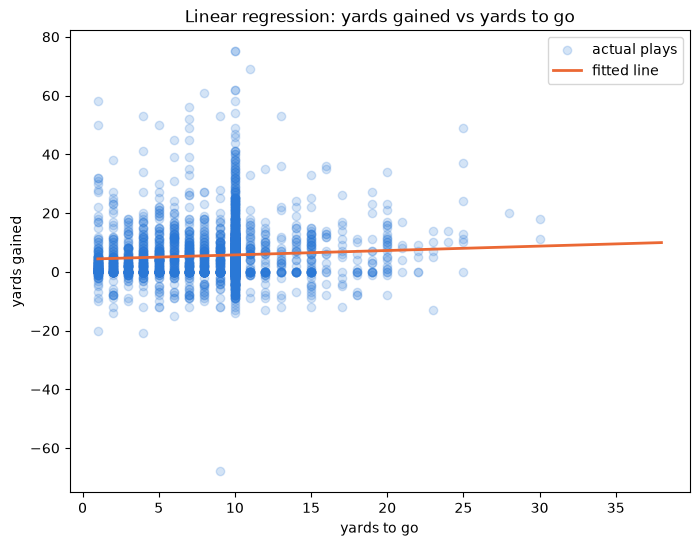

In [3]:
#visualise the fitted line against the test data
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_test, y_test, alpha=0.2, color='#2a78d6', label='actual plays')

x_range = np.linspace(X['yardsToGo'].min(), X['yardsToGo'].max(), 100).reshape(-1, 1)
ax.plot(x_range, model.predict(x_range), color='#eb6834', linewidth=2, label='fitted line')

ax.set_xlabel('yards to go')
ax.set_ylabel('yards gained')
ax.set_title('Linear regression: yards gained vs yards to go')
ax.legend()
plt.show()

In [4]:
#XGBoost modelling

from sklearn.datasets import make_classification
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

X, y = make_classification(
    n_samples=1000,
    n_features=5,
    n_informative=3,
    n_redundant=0,
    random_state=42,
)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model = XGBClassifier(n_estimators=100, max_depth=3, random_state=42)
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

print(f"accuracy: {accuracy_score(y_test, y_pred):.1%}")
print(f"baseline (always predict majority class): {max(y_test.mean(), 1 - y_test.mean()):.1%}")

accuracy: 96.5%
baseline (always predict majority class): 54.0%


In [5]:
#which features the model actually used to split on
importance = pd.Series(xgb_model.feature_importances_, index=[f'feature_{i}' for i in range(X.shape[1])])
importance.sort_values(ascending=False)

feature_2    0.682885
feature_4    0.153092
feature_3    0.098311
feature_0    0.034543
feature_1    0.031169
dtype: float32

In [6]:
#XGBoost on real data: predict isDropback from down, yardsToGo, and offensive formation
model_df = plays[['down', 'yardsToGo', 'offenseFormation', 'isDropback']].dropna()

X_real = pd.get_dummies(model_df[['down', 'yardsToGo', 'offenseFormation']], columns=['offenseFormation'], drop_first=True)
y_real = model_df['isDropback']

X_train, X_test, y_train, y_test = train_test_split(X_real, y_real, test_size=0.2, random_state=42, stratify=y_real)

xgb_real = XGBClassifier(n_estimators=100, max_depth=3, random_state=42)
xgb_real.fit(X_train, y_train)

y_pred = xgb_real.predict(X_test)

print(f"accuracy: {accuracy_score(y_test, y_pred):.1%}")
print(f"baseline (always predict majority class): {max(y_test.mean(), 1 - y_test.mean()):.1%}")

accuracy: 74.6%
baseline (always predict majority class): 60.9%


In [7]:
#which real features the model actually used to split on
importance_real = pd.Series(xgb_real.feature_importances_, index=X_real.columns)
importance_real.sort_values(ascending=False)

offenseFormation_SINGLEBACK    0.409089
offenseFormation_I_FORM        0.206692
offenseFormation_PISTOL        0.112863
down                           0.087528
offenseFormation_SHOTGUN       0.057878
offenseFormation_JUMBO         0.048040
offenseFormation_WILDCAT       0.043204
yardsToGo                      0.034706
dtype: float32

## Statistical modelling: hypothesis testing

Instead of predicting, these tests ask: is an observed difference real, or could it just be random chance?
Chi-square test (is dropback rate actually different across formations?).

In [8]:
#chi-square test of independence
from scipy.stats import chi2_contingency

contingency = pd.crosstab(plays['offenseFormation'], plays['isDropback'])

chi2, p_value, dof, expected = chi2_contingency(contingency)

print(f"chi2 statistic: {chi2:.2f}")
print(f"degrees of freedom: {dof}")
print(f"p-value: {p_value:.2e}")

if p_value < 0.05:
    print("significant (p < 0.05) - formation and dropback are not independent")
else:
    print("not significant - no evidence formation affects dropback rate")

contingency

chi2 statistic: 3451.59
degrees of freedom: 6
p-value: 0.00e+00
significant (p < 0.05) - formation and dropback are not independent


isDropback,False,True
offenseFormation,,
EMPTY,47,1295
I_FORM,736,299
JUMBO,104,21
PISTOL,415,226
SHOTGUN,2238,6553
SINGLEBACK,2609,1306
WILDCAT,74,13


In [9]:
from sklearn.metrics import precision_score, recall_score, log_loss

#precision: of the plays predicted as dropbacks, how many actually were?
precision = precision_score(y_test, y_pred)
print(f"precision: {precision:.1%}")

precision: 78.5%


In [10]:
#recall: of the plays that actually were dropbacks, how many did the model catch?
recall = recall_score(y_test, y_pred)
print(f"recall: {recall:.1%}")

recall: 80.3%


In [11]:
#log loss: uses predicted probabilities rather than just yes/no, penalizes confident wrong
#predictions harder than uncertain wrong ones. Lower is better (0 = perfect).
y_proba = xgb_real.predict_proba(X_test)
loss = log_loss(y_test, y_proba)
print(f"log loss: {loss:.3f}")

log loss: 0.520


In [12]:
#baseline log loss: always predict the training set's base dropback rate, for every play
baseline_proba = np.full(len(y_test), y_train.mean())
baseline_loss = log_loss(y_test, baseline_proba)
print(f"baseline log loss (always predict {y_train.mean():.1%}): {baseline_loss:.3f}")

baseline log loss (always predict 61.0%): 0.669
